# SHAP for Linear Models 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from tabulate import tabulate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [3]:
# set the fule URl and filename
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'
filename = 'wine.csv'

# Check if the file is in the current directory
try:
    wine = pd.read_csv(filename)
except FileNotFoundError:
    print(f'Downloading {filename}from {url} ...')
    wine = pd.read_csv(url, sep=";")
    wine.to_csv(filename, index=False)
    print('Download complete!')

In [4]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [5]:
summary = wine.describe().transpose().round(2)
summary = summary.drop("count", axis=1)

# create a markdown table
markdown_table = tabulate(
    summary, headers='keys', tablefmt='pipe'
)
print(markdown_table)

|                      |   mean |   std |   min |    25% |    50% |    75% |    max |
|:---------------------|-------:|------:|------:|-------:|-------:|-------:|-------:|
| fixed acidity        |   6.85 |  0.84 |  3.8  |   6.3  |   6.8  |   7.3  |  14.2  |
| volatile acidity     |   0.28 |  0.1  |  0.08 |   0.21 |   0.26 |   0.32 |   1.1  |
| citric acid          |   0.33 |  0.12 |  0    |   0.27 |   0.32 |   0.39 |   1.66 |
| residual sugar       |   6.39 |  5.07 |  0.6  |   1.7  |   5.2  |   9.9  |  65.8  |
| chlorides            |   0.05 |  0.02 |  0.01 |   0.04 |   0.04 |   0.05 |   0.35 |
| free sulfur dioxide  |  35.31 | 17.01 |  2    |  23    |  34    |  46    | 289    |
| total sulfur dioxide | 138.36 | 42.5  |  9    | 108    | 134    | 167    | 440    |
| density              |   0.99 |  0    |  0.99 |   0.99 |   0.99 |   1    |   1.04 |
| pH                   |   3.19 |  0.15 |  2.72 |   3.09 |   3.18 |   3.28 |   3.82 |
| sulphates            |   0.49 |  0.11 |  0.22 |   0.

In [6]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [7]:
wine.shape

(4898, 12)

In [8]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [9]:
new_columns = {
    'fixed acidity' : 'fixed_acidity',
    'volatile acidity' : 'volatile_acidity',
    'citric acid' : 'citric_acid',
    'residual sugar' : 'residual_sugar',
    'free sulfur dioxide' : 'free_sulfur_dioxide',
    'total sulfur dioxide' : 'total_sulfur_dioxide'
}

wine = wine.rename(columns=new_columns)


In [10]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         4898 non-null   float64
 1   volatile_acidity      4898 non-null   float64
 2   citric_acid           4898 non-null   float64
 3   residual_sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free_sulfur_dioxide   4898 non-null   float64
 6   total_sulfur_dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


### Boxplots - Looking For Outliers

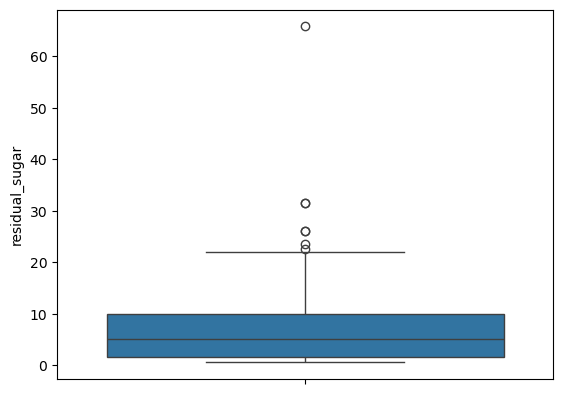

In [12]:
sns.boxplot(data=wine.residual_sugar);

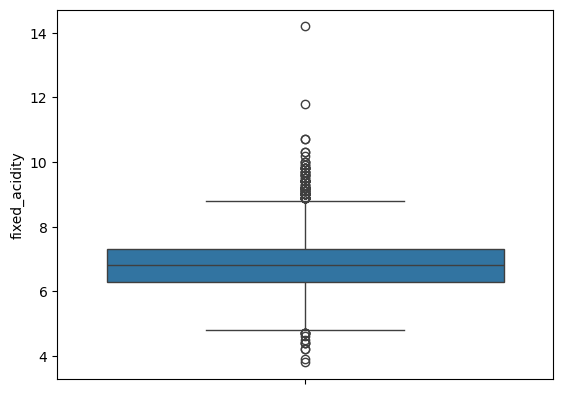

In [13]:
sns.boxplot(data=wine.fixed_acidity);

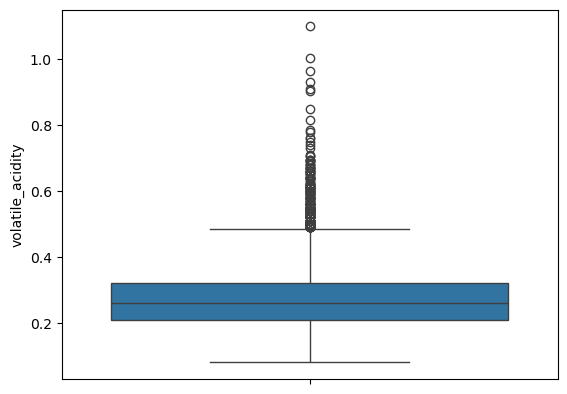

In [14]:
sns.boxplot(data=wine.volatile_acidity);

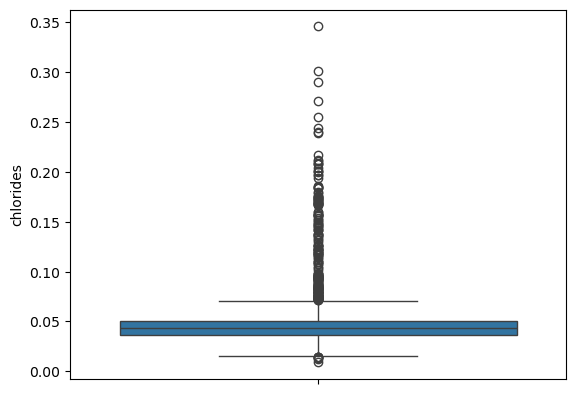

In [15]:
sns.boxplot(data=wine.chlorides);

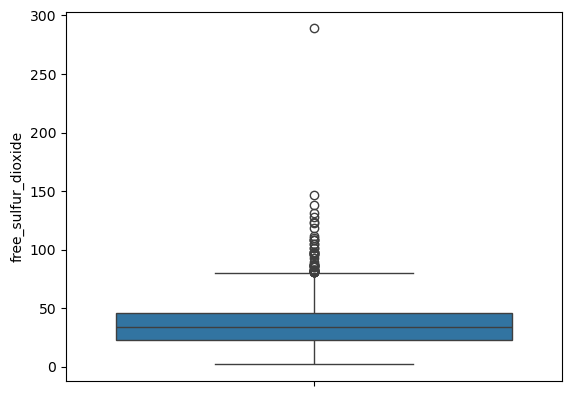

In [16]:
sns.boxplot(data=wine.free_sulfur_dioxide);

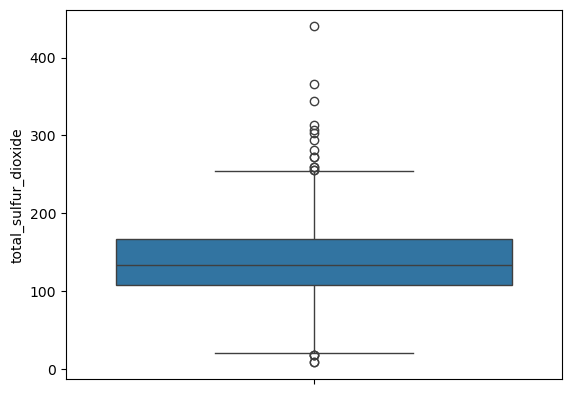

In [17]:
sns.boxplot(data=wine.total_sulfur_dioxide);

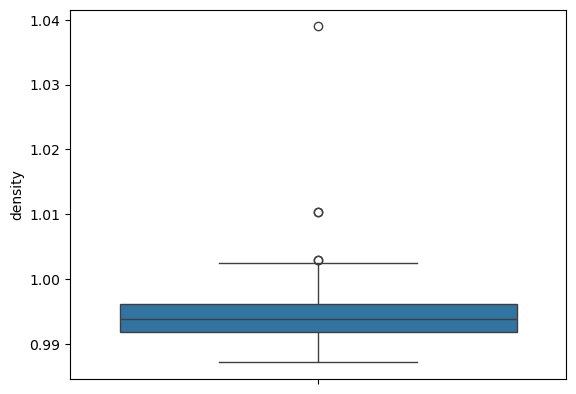

In [18]:
sns.boxplot(data=wine.density);

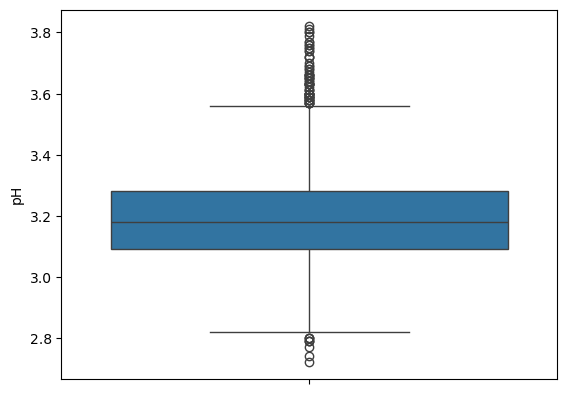

In [19]:
sns.boxplot(data=wine.pH);

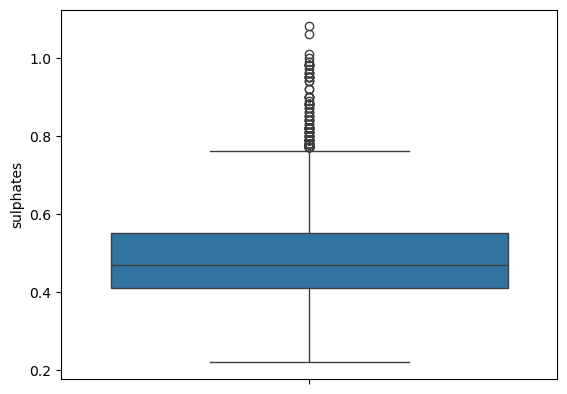

In [20]:
sns.boxplot(data=wine.sulphates );

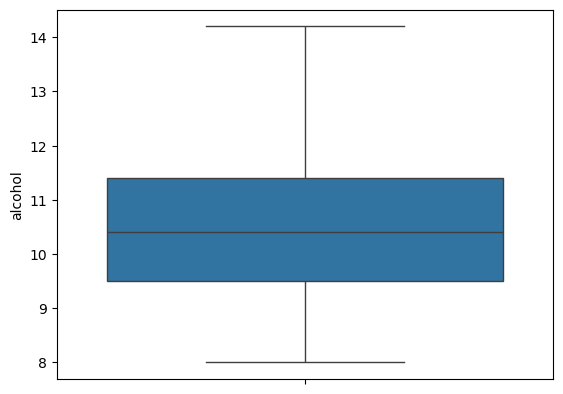

In [21]:
sns.boxplot(data=wine.alcohol);

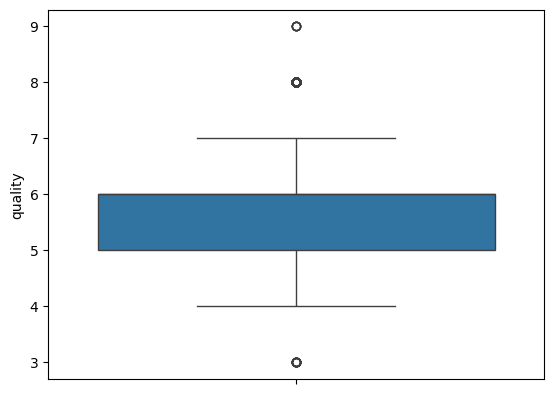

In [22]:
sns.boxplot(data=wine.quality);

#### Process Outliers With a For Loop

In [24]:
out_columns = ['pH', 'chlorides', 'fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'sulphates', 'alcohol', 'quality']

for column in out_columns:
    mean = wine[column].mean()
    std = wine[column].std()
    k=3
    lower_bound = mean - k * std
    upper_bound = mean + k * std
    wine[column] = np.where(wine[column] > upper_bound, upper_bound, wine[column])
    wine[column] = np.where(wine[column] < lower_bound, lower_bound, wine[column])


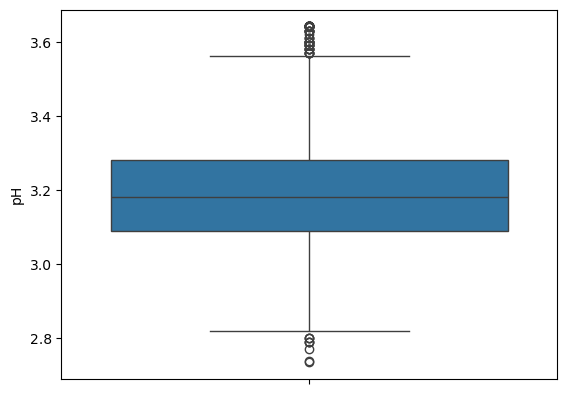

In [25]:
sns.boxplot(data=wine.pH);

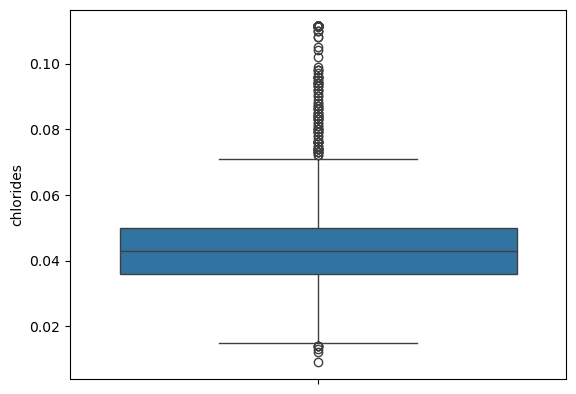

In [26]:
sns.boxplot(data=wine.chlorides);

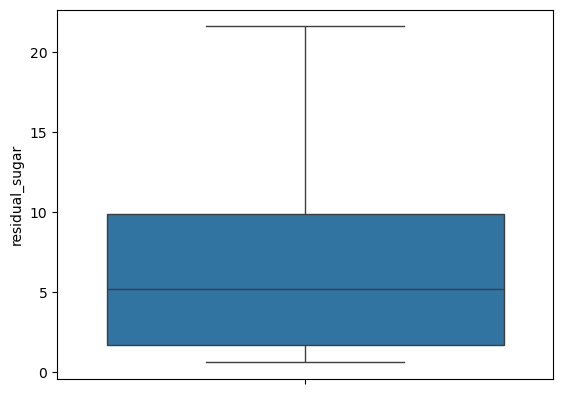

In [27]:
sns.boxplot(data=wine.residual_sugar);

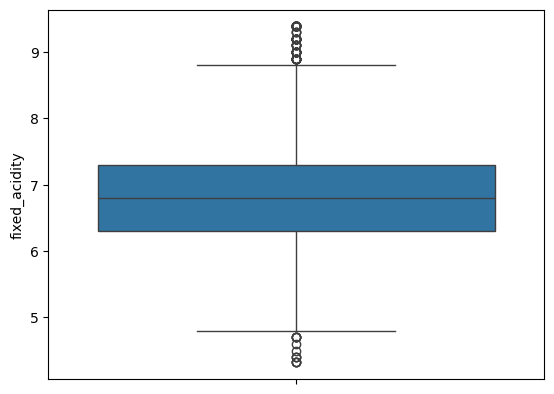

In [28]:
sns.boxplot(data=wine.fixed_acidity);

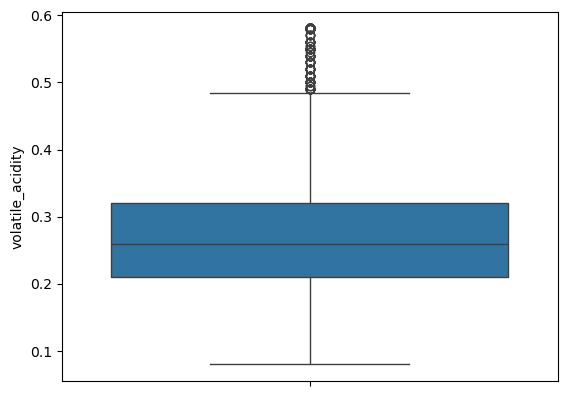

In [29]:
sns.boxplot(data=wine.volatile_acidity);

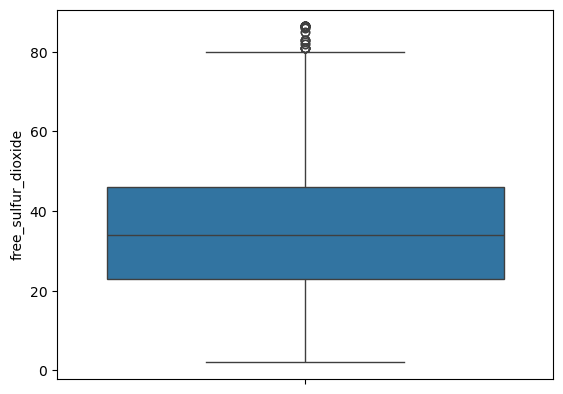

In [30]:
sns.boxplot(data=wine.free_sulfur_dioxide);

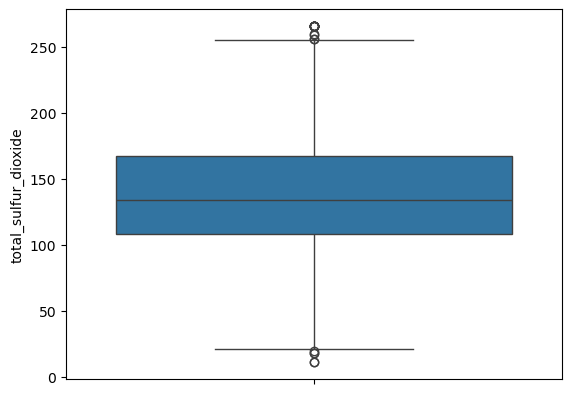

In [31]:
sns.boxplot(data=wine.total_sulfur_dioxide);

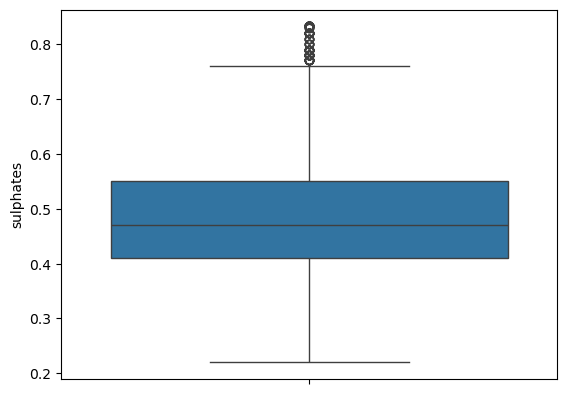

In [32]:
sns.boxplot(data=wine.sulphates );

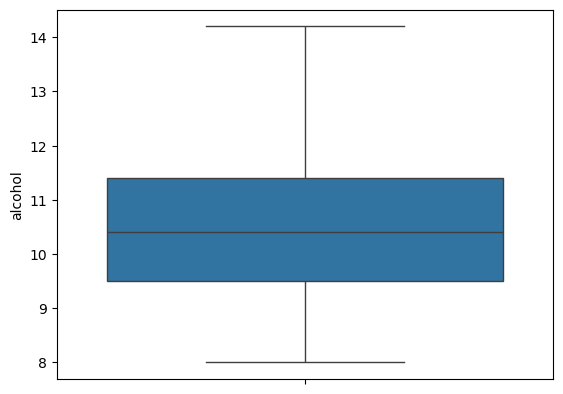

In [33]:
sns.boxplot(data=wine.alcohol);

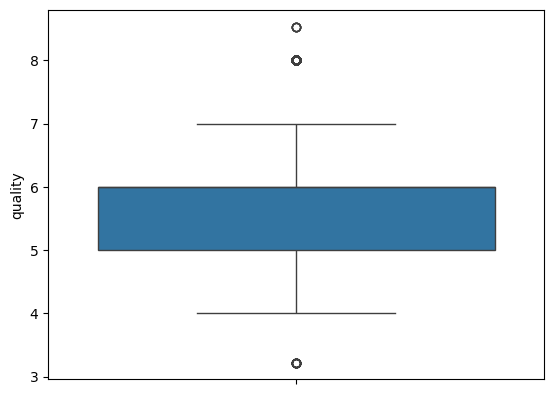

In [34]:
sns.boxplot(data=wine.quality);

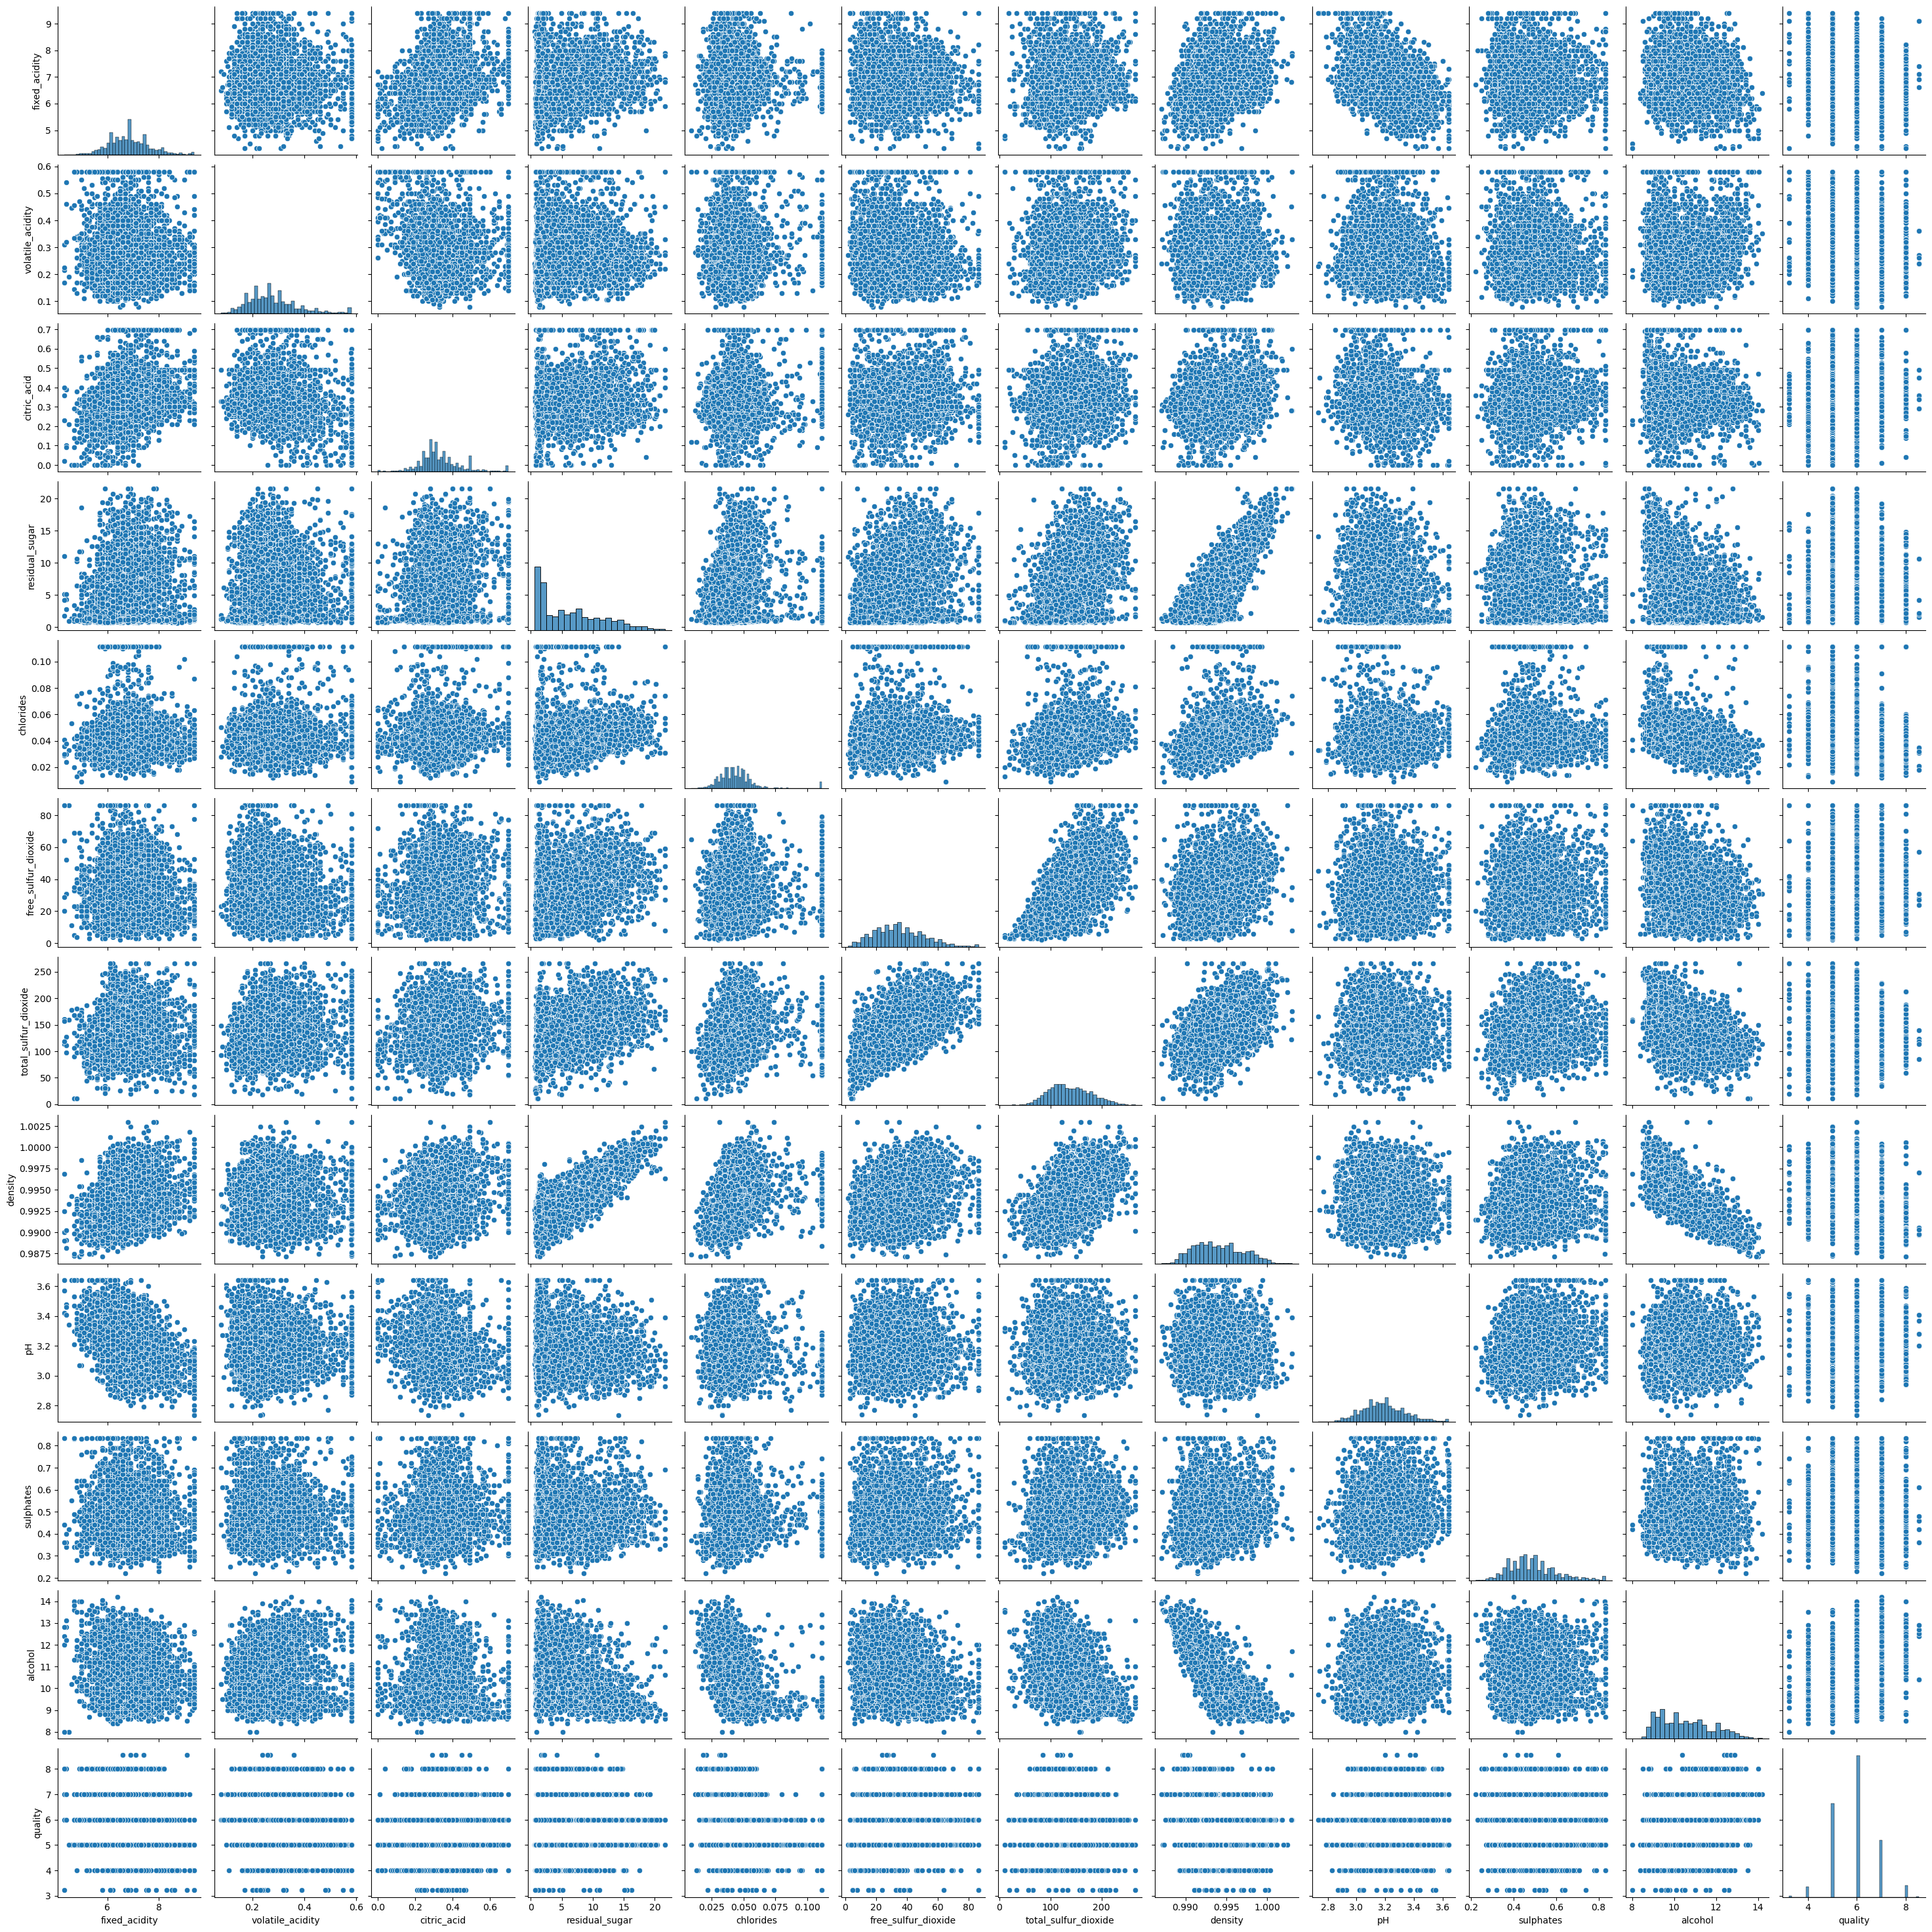

In [35]:
sns.pairplot(wine);

In [36]:
wine = wine.drop(index=0)
wine = wine.drop(index=182)
wine = wine.drop(index=191)
wine = wine.drop(index=1608)
wine = wine.drop(index=1653)
wine = wine.drop(index=1663)
wine = wine.drop(index=2781)
wine = wine.drop(index=3619)


#### Scaling Data

In [38]:
wine.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6.0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6.0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6.0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6.0
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6.0


In [39]:
wine.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,4890.0,6.850035,0.825401,4.323183,6.30000,6.80000,7.3000,9.386392
volatile_acidity,4890.0,0.276529,0.094121,0.080000,0.21000,0.26000,0.3200,0.580625
citric_acid,4890.0,0.332623,0.114621,0.000000,0.27000,0.32000,0.3900,0.697251
residual_sugar,4890.0,6.351015,4.946296,0.600000,1.70000,5.20000,9.8500,21.607588
chlorides,4890.0,0.044636,0.015152,0.009000,0.03600,0.04300,0.0500,0.111316
free_sulfur_dioxide,4890.0,35.142852,16.147356,2.000000,23.00000,34.00000,46.0000,86.329497
total_sulfur_dioxide,4890.0,138.197297,42.034712,10.866464,108.00000,134.00000,167.0000,265.854851
density,4890.0,0.994004,0.002894,0.987110,0.99172,0.99373,0.9961,1.002950
pH,4890.0,3.187976,0.149295,2.735265,3.09000,3.18000,3.2800,3.641268
sulphates,4890.0,0.488991,0.110966,0.220000,0.41000,0.47000,0.5500,0.832224


In [40]:
wine['residual_sugar'].idxmax()

# df['A'].max()


3623

In [41]:
scaler = StandardScaler()

In [42]:
wine[['free_sulfur_dioxide', 'total_sulfur_dioxide']] = scaler.fit_transform(wine[['free_sulfur_dioxide', 'total_sulfur_dioxide']])

# df[['A', 'B']] = scaler.fit_transform(df[['A', 'B']])

In [43]:
wine.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,4890.0,6.850035e+00,0.825401,4.323183,6.300000,6.800000,7.300000,9.386392
volatile_acidity,4890.0,2.765286e-01,0.094121,0.080000,0.210000,0.260000,0.320000,0.580625
citric_acid,4890.0,3.326230e-01,0.114621,0.000000,0.270000,0.320000,0.390000,0.697251
residual_sugar,4890.0,6.351015e+00,4.946296,0.600000,1.700000,5.200000,9.850000,21.607588
chlorides,4890.0,4.463604e-02,0.015152,0.009000,0.036000,0.043000,0.050000,0.111316
free_sulfur_dioxide,4890.0,-6.538737e-18,1.000102,-2.052735,-0.752079,-0.070784,0.672448,3.170295
total_sulfur_dioxide,4890.0,5.114745e-16,1.000102,-3.029493,-0.718463,-0.099863,0.685282,3.037266
density,4890.0,9.940037e-01,0.002894,0.987110,0.991720,0.993730,0.996100,1.002950
pH,4890.0,3.187976e+00,0.149295,2.735265,3.090000,3.180000,3.280000,3.641268
sulphates,4890.0,4.889912e-01,0.110966,0.220000,0.410000,0.470000,0.550000,0.832224


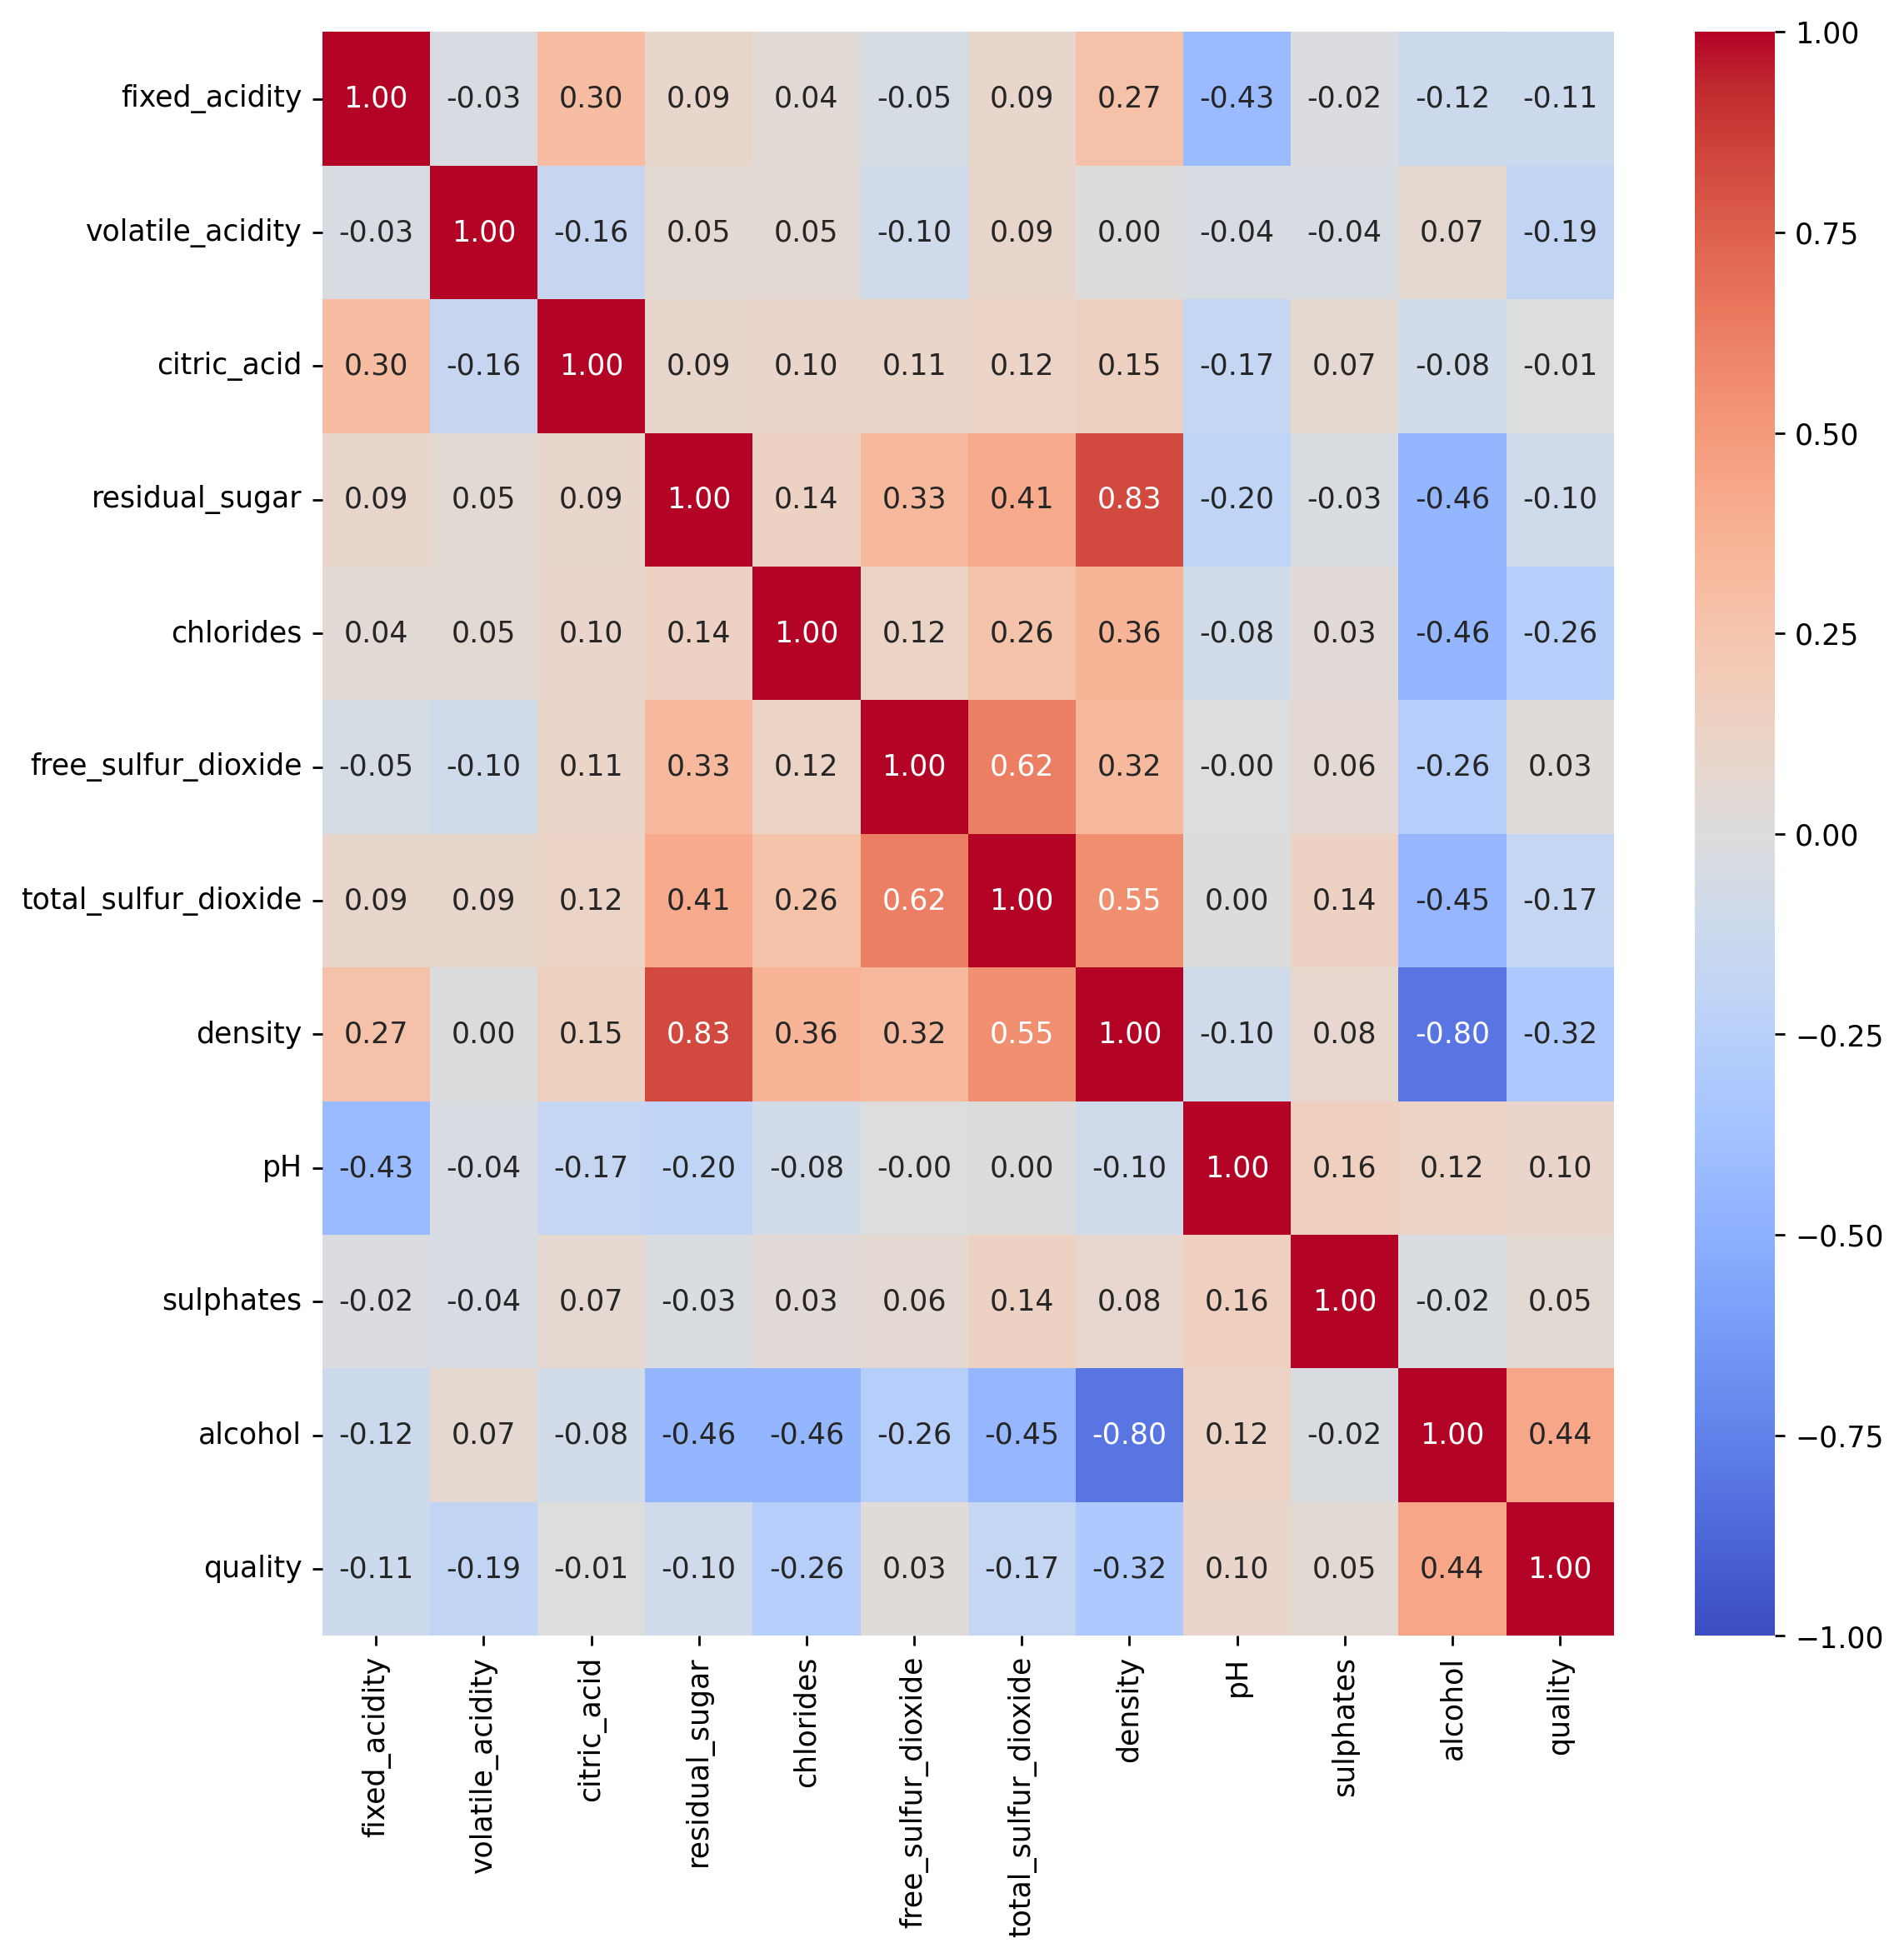

In [44]:
plt.figure(figsize=(10,10), dpi=250)
sns.heatmap(data=wine.corr(), annot=True, fmt="0.2f", vmax=1, vmin=-1, cmap="coolwarm");

In [45]:
y = wine['quality']
X = wine.drop('quality', axis=1)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Create the Model

In [48]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Model Evaluation

In [50]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE: 0.563
MSE: 0.520
RMSE: 0.721


### Interpreting the Coefficients

In [52]:
coefs = pd.DataFrame({
    'feature': X.columns.values,
    'coefficient': np.round(model.coef_, 3)
}) 
print(coefs.to_markdown(index=False))

| feature              |   coefficient |
|:---------------------|--------------:|
| fixed_acidity        |         0.156 |
| volatile_acidity     |        -1.971 |
| citric_acid          |        -0.002 |
| residual_sugar       |         0.114 |
| chlorides            |        -0.027 |
| free_sulfur_dioxide  |         0.087 |
| total_sulfur_dioxide |         0.007 |
| density              |      -255.063 |
| pH                   |         1.011 |
| sulphates            |         0.752 |
| alcohol              |         0.064 |


## SHAP Values

In [54]:
explainer = shap.LinearExplainer(model, X_train)

In [55]:
shap_values = explainer(X_test)

In [56]:
print(shap_values.values)

[[-7.58927937e-02  3.70585268e-02 -1.03953588e-04 ... -1.95500391e-01
  -8.91183640e-02  2.61620725e-02]
 [ 2.02588566e-03  1.06027545e-01  3.26627256e-05 ...  1.98709289e-01
   1.96742299e-01  7.07340995e-03]
 [ 2.02588566e-03 -9.10267930e-02 -3.56454314e-05 ... -3.44952108e-03
  -8.15957150e-02 -8.83699027e-02]
 ...
 [-4.47253220e-02  4.69112437e-02 -2.86108674e-04 ...  6.65841945e-03
   1.61987222e-02 -8.83699027e-02]
 [-2.91415861e-02  1.06027545e-01 -1.03953588e-04 ... -1.75284510e-01
  -8.15957150e-02 -7.56441277e-02]
 [-1.53811473e-01  1.65143847e-01 -1.28760457e-05 ... -3.37733427e-02
  -6.65504170e-02  5.16136225e-02]]


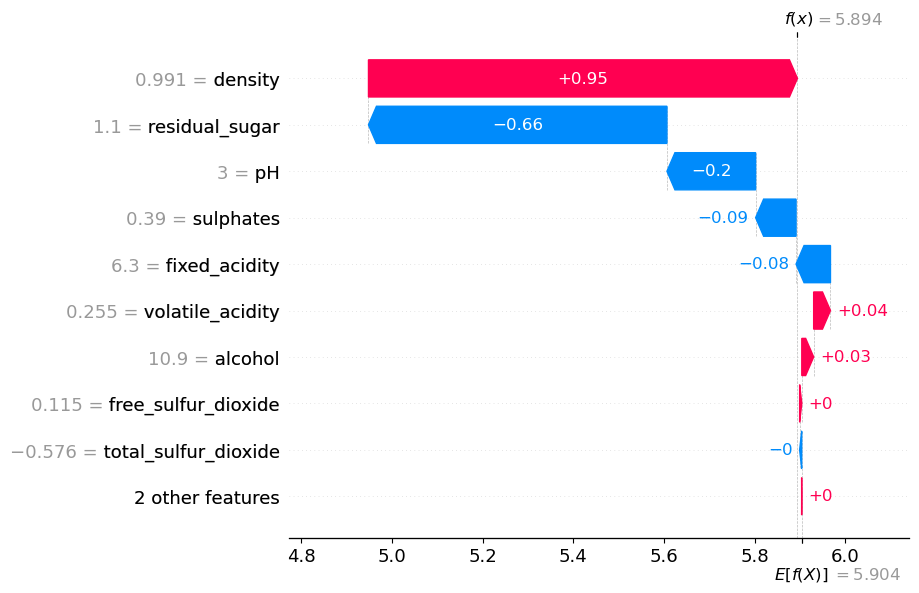

In [57]:
shap.plots.waterfall(shap_values[0])

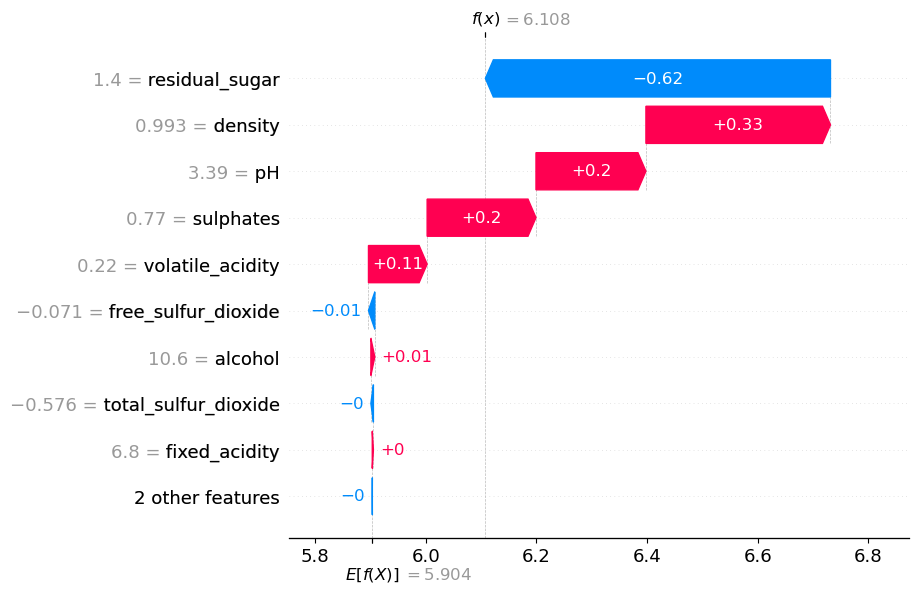

In [58]:
shap.plots.waterfall(shap_values[1])

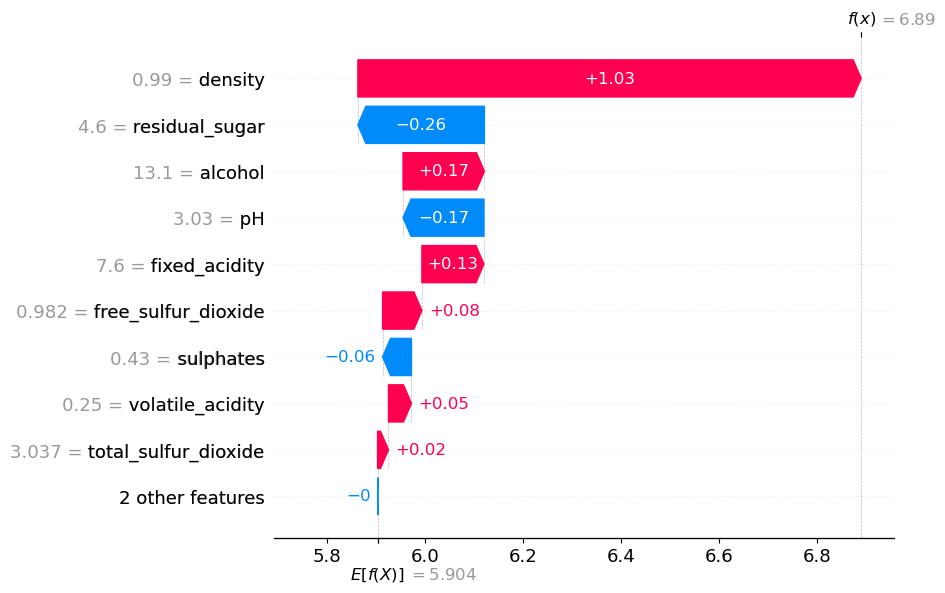

In [59]:
shap.plots.waterfall(shap_values[63])

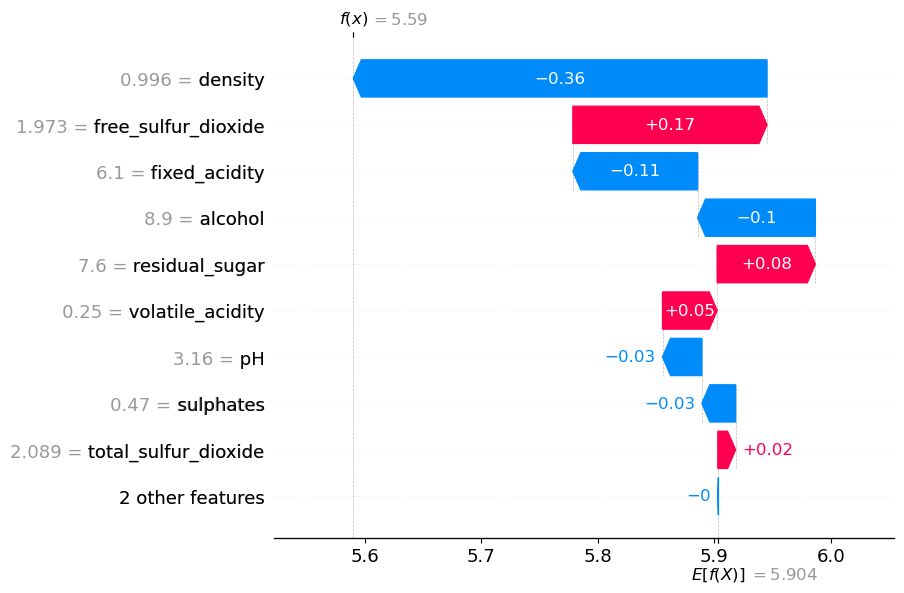

In [60]:
shap.plots.waterfall(shap_values[549])

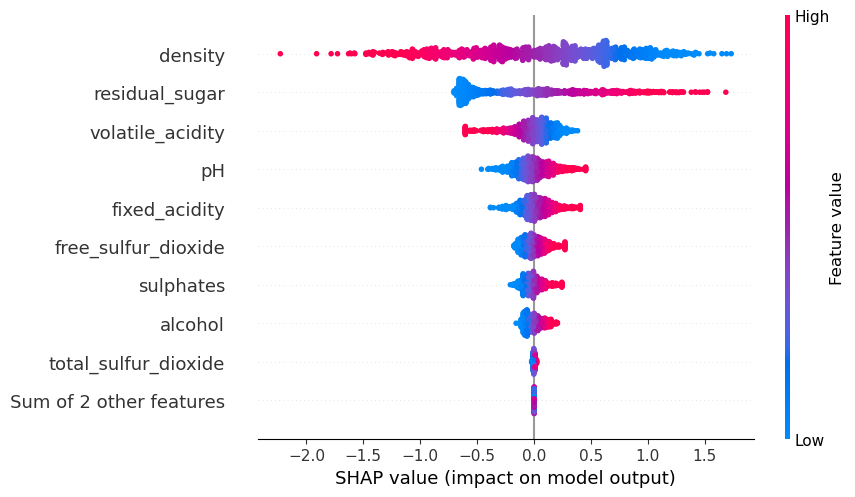

In [61]:
shap.plots.beeswarm(shap_values)

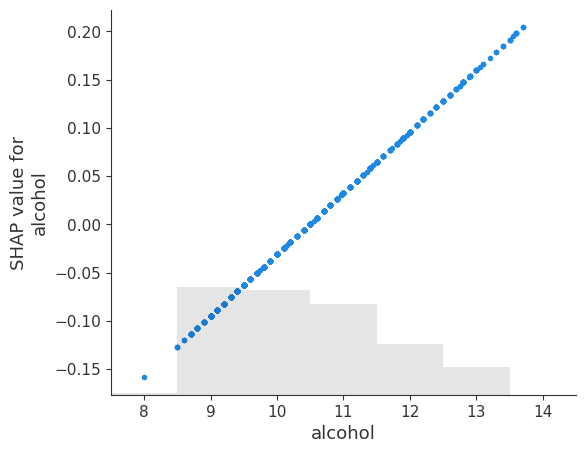

In [119]:
shap.plots.scatter(shap_values[:,'alcohol']);